In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt


In [5]:

df = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")


In [6]:
y = df["oxygen"]

# predictors: ONLY multivariate wavelengths
wl_cols = [c for c in df.columns if c.startswith("PRrs")]
X = df[wl_cols]

In [7]:
mask = X.notnull().all(axis=1) & y.notnull()
X = X.loc[mask]
y = y.loc[mask]

print("Samples used:", len(y))
print("Number of wavelengths:", len(wl_cols))


Samples used: 853
Number of wavelengths: 172


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
model = Pipeline([
    ("scaler", StandardScaler()),   # scale PRrs wavelengths
    ("ridge", Ridge(alpha=10.0))    # L2-regularized linear regression
])

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.20726613459033583
RMSE: 1.1585992716847577


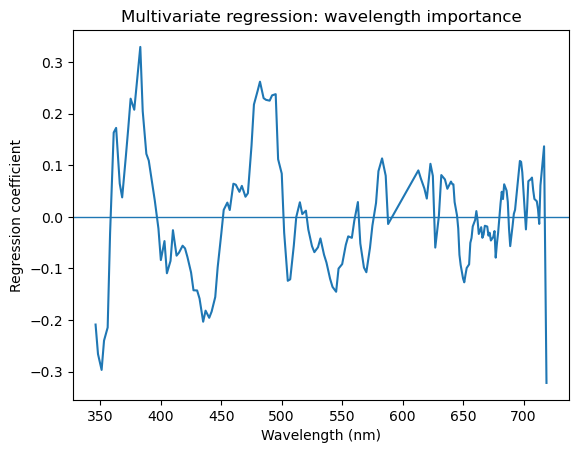

In [10]:
coef = model.named_steps["ridge"].coef_
coef_s = pd.Series(coef, index=wl_cols)

# numeric wavelengths for plotting
wavelengths = np.array([int(c.replace("PRrs", "")) for c in wl_cols])
order = np.argsort(wavelengths)


plt.plot(wavelengths[order], coef_s.values[order])
plt.axhline(0, linewidth=1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Regression coefficient")
plt.title("Multivariate regression: wavelength importance")
plt.show()
####